# Feature Engineering and preprocessing

In [1]:
# importing libraries
import pandas as pd
import numpy as np
# loading the raw dataset
df = pd.read_csv('../../data/raw/Fraudtrain.csv')

##### Extract features from trans_date_trans_time

In [2]:
# Convert trans_date_trans_time to pandas datetime
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# Extract the transaction hour column
df['trans_hour'] = df['trans_date_trans_time'].dt.hour

# Extract the transaction month column
df['trans_month'] = df['trans_date_trans_time'].dt.month 

# Extract the day of the week
df['trans_dayofweek'] = df['trans_date_trans_time'].dt.day_name()

In [3]:
# Verify the new columns
print(df[['trans_date_trans_time', 'trans_hour', 'trans_month', 'trans_dayofweek']].head())

  trans_date_trans_time  trans_hour  trans_month trans_dayofweek
0   2019-01-01 00:00:18           0            1         Tuesday
1   2019-01-01 00:00:44           0            1         Tuesday
2   2019-01-01 00:00:51           0            1         Tuesday
3   2019-01-01 00:01:16           0            1         Tuesday
4   2019-01-01 00:03:06           0            1         Tuesday


In [4]:
df['trans_hour'].unique() # printing the unique values in the extracted series

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23])

In [5]:
df['trans_month'].unique() # printing the unique values in the extracted series

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [6]:
df['trans_dayofweek'].unique() # printing the unique values in the extracted series

array(['Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday',
       'Monday'], dtype=object)

##### Extract features from unix_time

In [7]:
# Convert unix_time to datetime
df['transaction_time'] = pd.to_datetime(df['unix_time'], unit='s')

# Sort by user (cc_num) and transaction time
df = df.sort_values(by=['cc_num', 'transaction_time'])

# Calculate the previous transaction time using shift
df['unix_time_prev_trans'] = df.groupby(by=['cc_num'])['unix_time'].shift(1)

# Create a new DataFrame with the filled values
df = df.assign(unix_time_prev_trans=df['unix_time_prev_trans'].fillna(df['unix_time'] - 86400))

# Calculate the time delta in minutes between the previous and current transaction
df['timedelta_last_trans'] = (df['unix_time'] - df['unix_time_prev_trans']) // 60
df['timedelta_last_trans'].head()


1017    1440.0
2724    1197.0
2726       2.0
2882     230.0
2907      32.0
Name: timedelta_last_trans, dtype: float64

##### Extract features from dob

In [8]:
# Convert columns to datetime
df['dob'] = pd.to_datetime(df['dob'])
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# Calculate age at the time of transaction
df['cust_age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365

# Display the result
print(df['cust_age'].head())

1017    32
2724    32
2726    32
2882    32
2907    32
Name: cust_age, dtype: int64


##### Extracting features from customer lat/long and merchant lat/long

In [9]:
# Define the Haversine function
def haversine(lat1, lon1, lat2, lon2):
    # Convert decimal degrees to radians
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lon2])
    
    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    
    # Radius of earth in kilometers is 6371
    km = 6371 * c
    return km

# Create a new DataFrame to perform calculations
df_calc = pd.DataFrame(df)

# Sort by user (cc_num) to ensure correct order of transactions
df_calc = df_calc.sort_values(by=['cc_num'])

# Shift latitude and longitude of the previous merchant to get the previous transaction's coordinates
df_calc['prev_merch_lat'] = df_calc.groupby('cc_num')['merch_lat'].shift(1)
df_calc['prev_merch_long'] = df_calc.groupby('cc_num')['merch_long'].shift(1)

# Fill null values with the current merchant's coordinates using assign method
df_calc = df_calc.assign(
    prev_merch_lat=df_calc['prev_merch_lat'].fillna(df_calc['merch_lat']),
    prev_merch_long=df_calc['prev_merch_long'].fillna(df_calc['merch_long'])
)

# Calculate the distance using the Haversine formula
df_calc['distance_from_prev_merch'] = df_calc.apply(
    lambda row: haversine(row['merch_lat'], row['merch_long'], row['prev_merch_lat'], row['prev_merch_long']), axis=1
)

# Display the first few distances
df_calc['distance_from_prev_merch'].head()

1017      17092.507729
847919    16948.058741
847911    16927.249111
847888    16814.906255
844274    16812.276483
Name: distance_from_prev_merch, dtype: float64

In [10]:
# Add the calculated distances back to the original DataFrame
df['distance_from_prev_merch'] = df_calc['distance_from_prev_merch']
df['distance_from_prev_merch'].head()

1017    17092.507729
2724    16810.034615
2726    16869.192226
2882    16714.557097
2907    16988.374462
Name: distance_from_prev_merch, dtype: float64

In [11]:
list(df.columns)

['Unnamed: 0',
 'trans_date_trans_time',
 'cc_num',
 'merchant',
 'category',
 'amt',
 'first',
 'last',
 'gender',
 'street',
 'city',
 'state',
 'zip',
 'lat',
 'long',
 'city_pop',
 'job',
 'dob',
 'trans_num',
 'unix_time',
 'merch_lat',
 'merch_long',
 'is_fraud',
 'trans_hour',
 'trans_month',
 'trans_dayofweek',
 'transaction_time',
 'unix_time_prev_trans',
 'timedelta_last_trans',
 'cust_age',
 'distance_from_prev_merch']

In [12]:
!pip install geopy

In [13]:
from sklearn.cluster import KMeans
from geopy.distance import geodesic

# Function to check if the transaction is during business hours
def is_business_hours(hour):
    return 1 if 9 <= hour <= 18 else 0

# Function to check if the transaction occurred on a weekend
def is_weekend(day):
    return 1 if day in ['Saturday', 'Sunday'] else 0

# Add business hours and weekend features
df['business_hours'] = df['trans_hour'].apply(is_business_hours)
df['weekend'] = df['trans_dayofweek'].apply(is_weekend)

# Add merchant location clusters
coords = df[['merch_lat', 'merch_long']].dropna().values
kmeans = KMeans(n_clusters=10, random_state=42)
df['merchant_cluster'] = kmeans.fit_predict(coords)

# Calculate the distance between customer city and merchant city if applicable
# For simplicity, let's assume the coordinates of customer city are available
# in the 'lat' and 'long' columns
def calculate_customer_to_merchant_distance(row):
    customer_coords = (row['lat'], row['long'])
    merchant_coords = (row['merch_lat'], row['merch_long'])
    return geodesic(customer_coords, merchant_coords).kilometers

df['customer_to_merchant_distance'] = df.apply(calculate_customer_to_merchant_distance, axis=1)

# Calculate average transaction amount per credit card
df['avg_amt_per_cc'] = df.groupby('cc_num')['amt'].transform('mean')

# Calculate transaction frequency per day for the same credit card
df['trans_freq_per_day'] = df.groupby(['cc_num', df['transaction_time'].dt.date])['trans_date_trans_time'].transform('count')

# Create interaction features
df['amt_trans_hour_interaction'] = df['amt'] * df['trans_hour']
df['cust_age_amt_interaction'] = df['cust_age'] * df['amt']

In [14]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,cust_age,distance_from_prev_merch,business_hours,weekend,merchant_cluster,customer_to_merchant_distance,avg_amt_per_cc,trans_freq_per_day,amt_trans_hour_interaction,cust_age_amt_interaction
1017,1017,2019-01-01 12:47:15,60416207185,"fraud_Jones, Sawayn and Romaguera",misc_net,7.27,Mary,Diaz,F,9886 Anita Drive,...,32,17092.507729,1,0,3,127.629296,56.023366,1,87.24,232.64
2724,2724,2019-01-02 08:44:57,60416207185,fraud_Berge LLC,gas_transport,52.94,Mary,Diaz,F,9886 Anita Drive,...,32,16810.034615,0,0,3,110.202992,56.023366,4,423.52,1694.08
2726,2726,2019-01-02 08:47:36,60416207185,fraud_Luettgen PLC,gas_transport,82.08,Mary,Diaz,F,9886 Anita Drive,...,32,16869.192226,0,0,3,21.841827,56.023366,4,656.64,2626.56
2882,2882,2019-01-02 12:38:14,60416207185,fraud_Daugherty LLC,kids_pets,34.79,Mary,Diaz,F,9886 Anita Drive,...,32,16714.557097,1,0,3,87.124420,56.023366,4,417.48,1113.28
2907,2907,2019-01-02 13:10:46,60416207185,fraud_Beier and Sons,home,27.18,Mary,Diaz,F,9886 Anita Drive,...,32,16988.374462,1,0,3,74.352876,56.023366,4,353.34,869.76


In [15]:
list(df.columns)

['Unnamed: 0',
 'trans_date_trans_time',
 'cc_num',
 'merchant',
 'category',
 'amt',
 'first',
 'last',
 'gender',
 'street',
 'city',
 'state',
 'zip',
 'lat',
 'long',
 'city_pop',
 'job',
 'dob',
 'trans_num',
 'unix_time',
 'merch_lat',
 'merch_long',
 'is_fraud',
 'trans_hour',
 'trans_month',
 'trans_dayofweek',
 'transaction_time',
 'unix_time_prev_trans',
 'timedelta_last_trans',
 'cust_age',
 'distance_from_prev_merch',
 'business_hours',
 'weekend',
 'merchant_cluster',
 'customer_to_merchant_distance',
 'avg_amt_per_cc',
 'trans_freq_per_day',
 'amt_trans_hour_interaction',
 'cust_age_amt_interaction']

<Axes: >

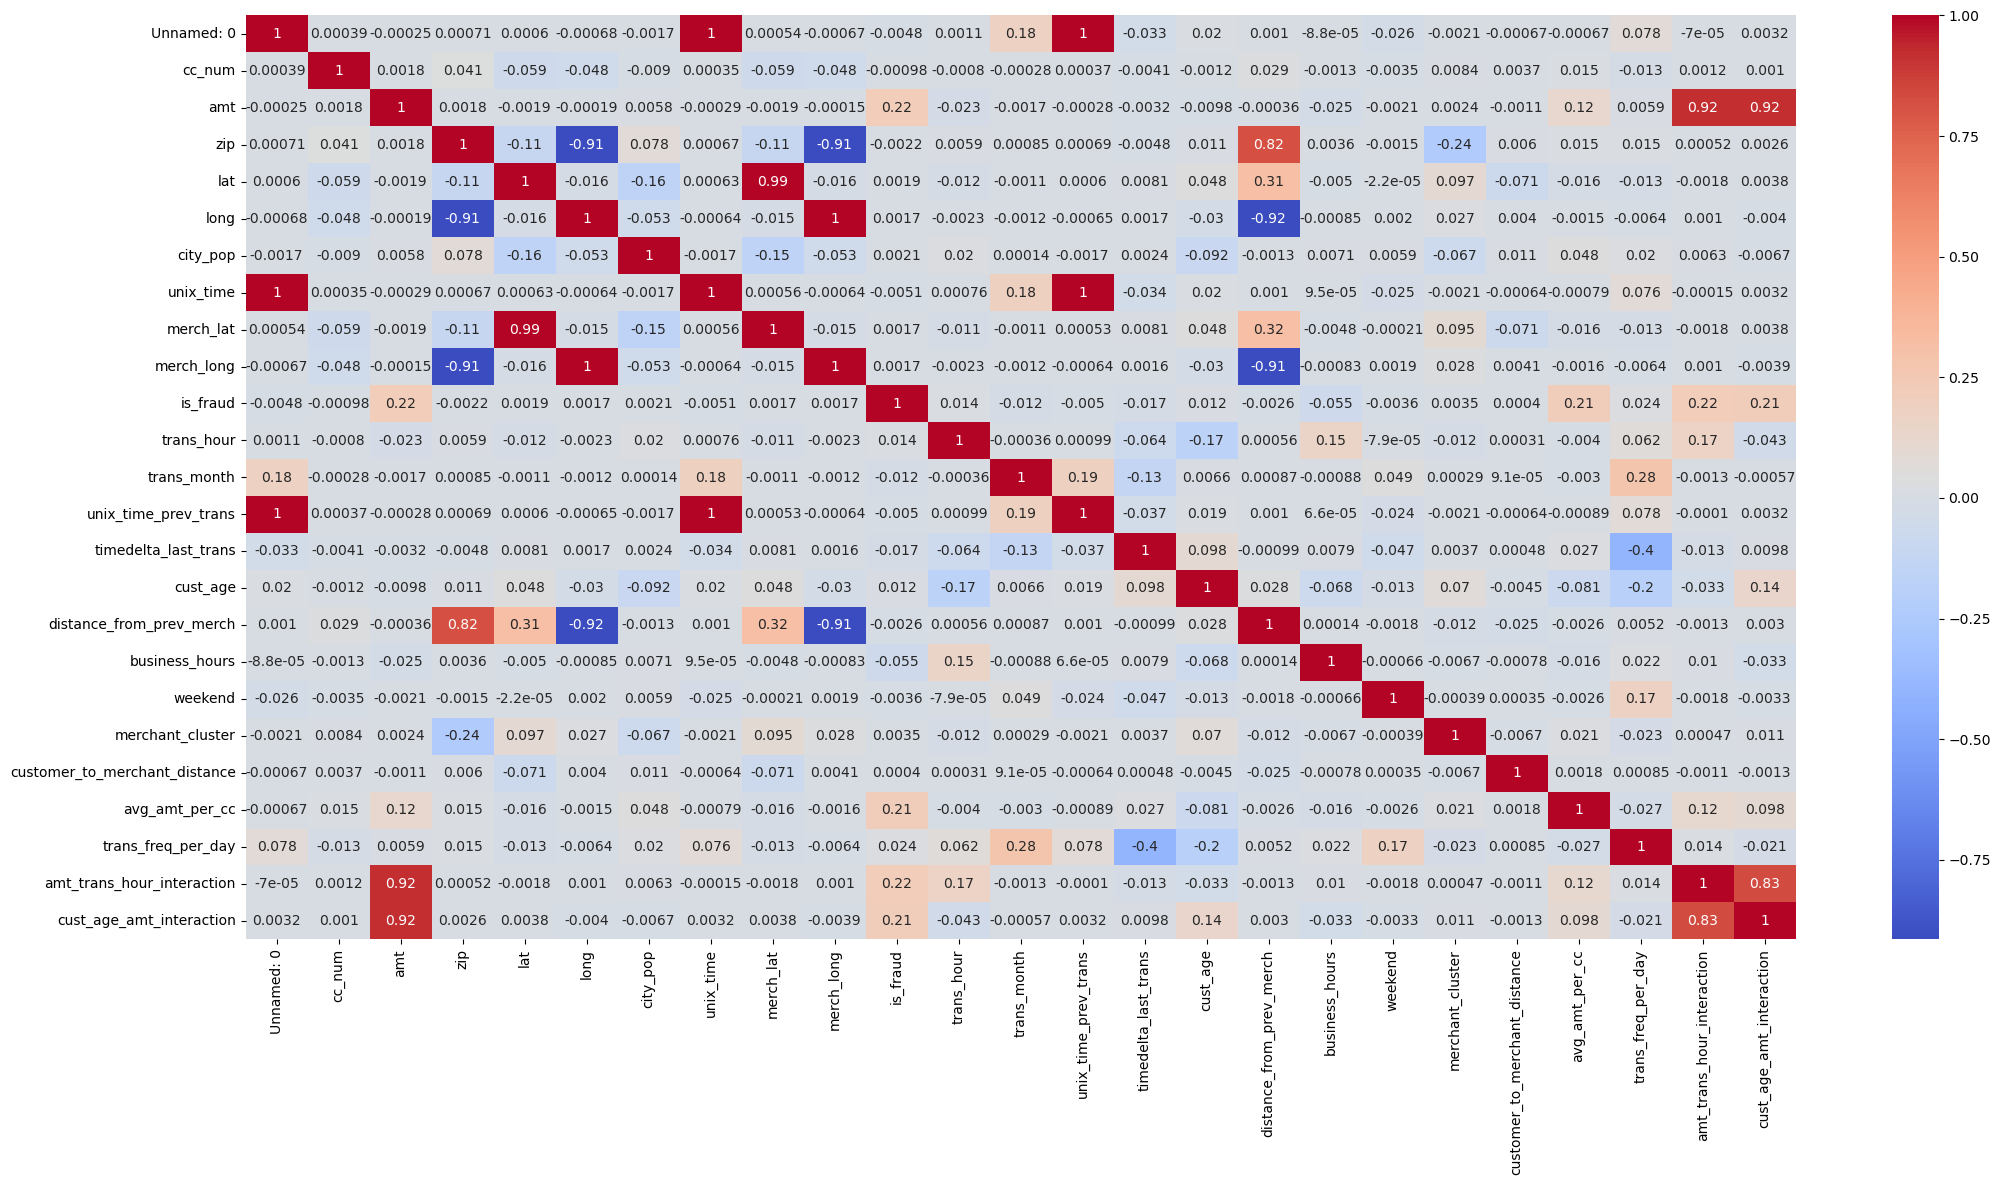

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
# Specify the numeric_only parameter 
corr_matrix = df.corr(numeric_only=True)

# Create a heatmap for the correlation matrix
fig = plt.figure(figsize=(25, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True)

In [17]:
# List of columns to drop
drop_cols = [
    'Unnamed: 0', 'street', 'zip', 'first', 'last', 'trans_num', 'trans_date_trans_time',
    'transaction_time', 'cc_num', 'unix_time', 'unix_time_prev_trans', 'lat', 'long',
    'merch_lat', 'merch_long', 'dob'
]

# Dropping the columns from the DataFrame
df = df.drop(columns=drop_cols)

# Display the remaining columns
print("Remaining Features:")
print(df.columns)

Remaining Features:
Index(['merchant', 'category', 'amt', 'gender', 'city', 'state', 'city_pop',
       'job', 'is_fraud', 'trans_hour', 'trans_month', 'trans_dayofweek',
       'timedelta_last_trans', 'cust_age', 'distance_from_prev_merch',
       'business_hours', 'weekend', 'merchant_cluster',
       'customer_to_merchant_distance', 'avg_amt_per_cc', 'trans_freq_per_day',
       'amt_trans_hour_interaction', 'cust_age_amt_interaction'],
      dtype='object')


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1296675 entries, 1017 to 1296427
Data columns (total 23 columns):
 #   Column                         Non-Null Count    Dtype  
---  ------                         --------------    -----  
 0   merchant                       1296675 non-null  object 
 1   category                       1296675 non-null  object 
 2   amt                            1296675 non-null  float64
 3   gender                         1296675 non-null  object 
 4   city                           1296675 non-null  object 
 5   state                          1296675 non-null  object 
 6   city_pop                       1296675 non-null  int64  
 7   job                            1296675 non-null  object 
 8   is_fraud                       1296675 non-null  int64  
 9   trans_hour                     1296675 non-null  int32  
 10  trans_month                    1296675 non-null  int32  
 11  trans_dayofweek                1296675 non-null  object 
 12  timedelta_last_t

#### Splitting the train datasets 70% train, 30 % validation

- The aim to do splitting before any econding and normalization is to prevent data leakage from the target into the train
- to avoid over fitting and improve the model's robustness

In [19]:
# splitting the train datasets into X and y
X = df.drop(columns=["is_fraud"])
y = df["is_fraud"]

# importing splitting module from sklearn
from sklearn.model_selection import train_test_split
# splitting the X and y into train and validate, using stratify split to ensure equal ratio of fraud and genuine 
# between the train and validate as the datasets is highly imbalanced
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size = 0.3, random_state = 42)
print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)

(907672, 22)
(389003, 22)
(907672,)
(389003,)


#### handling outliers and normalisation on train dataset

In [20]:
# installing features enngine
!pip install feature_engine

In [21]:
# Selecting numerical columns
num_cols = X_train.select_dtypes(include = np.number).columns

num_cols

Index(['amt', 'city_pop', 'trans_hour', 'trans_month', 'timedelta_last_trans',
       'cust_age', 'distance_from_prev_merch', 'business_hours', 'weekend',
       'merchant_cluster', 'customer_to_merchant_distance', 'avg_amt_per_cc',
       'trans_freq_per_day', 'amt_trans_hour_interaction',
       'cust_age_amt_interaction'],
      dtype='object')

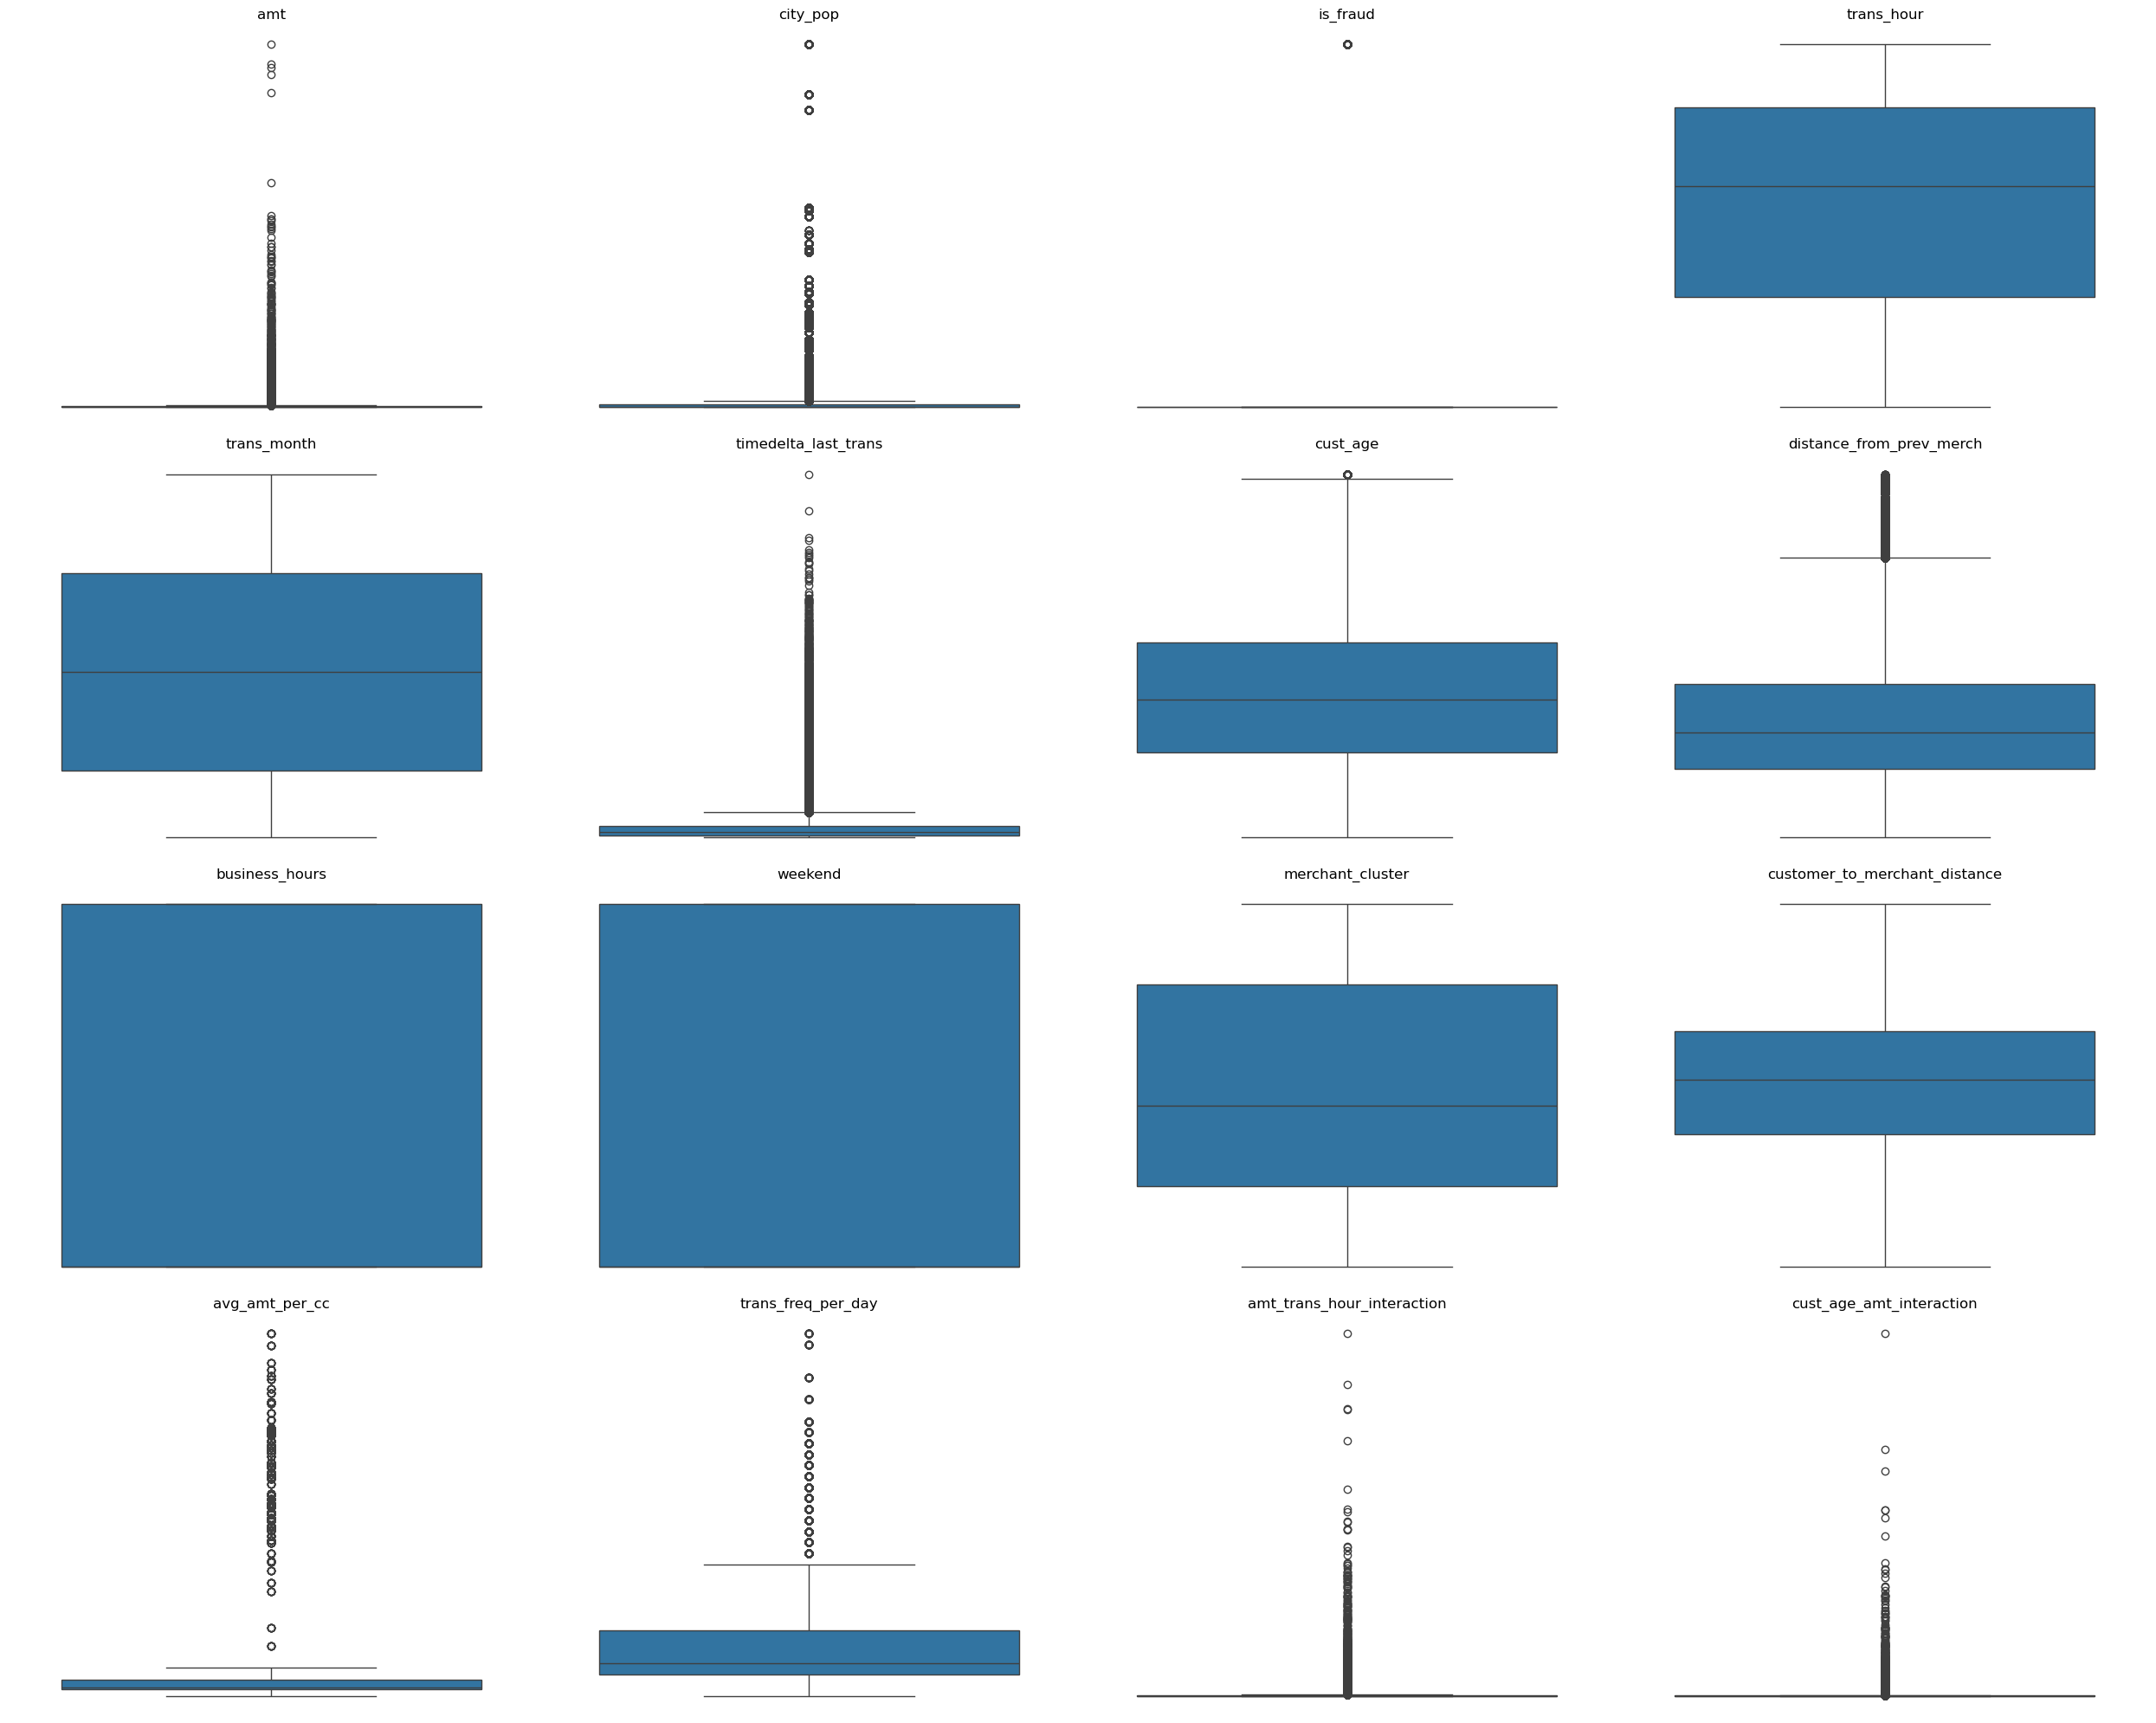

In [22]:
# List of numerical columns
num_cols = df.select_dtypes(include=[np.number]).columns

# Number of numerical columns
num_cols_count = len(num_cols)

# Determine the grid size
rows = (num_cols_count // 4) + 1 if num_cols_count % 4 != 0 else num_cols_count // 4
cols = 4

# Plotting
plt.figure(figsize=(25, 5 * rows))  # Adjust height to accommodate more rows

for ind, col_name in enumerate(num_cols):
    plot_var = df[col_name]
    plt.subplot(rows, cols, ind + 1)
    sns.boxplot(plot_var)
    plt.title(col_name)
    plt.axis(False)  # Hide axis to make the plot clearer

plt.tight_layout()  # Adjust layout to prevent overlapping
plt.show()


In [23]:
# importing Winsorizer to cap the outlers using IQR
from feature_engine.outliers import Winsorizer
# outliers to be capped
outliers = ['amt', 'city_pop', 'timedelta_last_trans', 'distance_from_prev_merch','avg_amt_per_cc', 'trans_freq_per_day',
       'amt_trans_hour_interaction', 'cust_age_amt_interaction'] 
# choosing the IQR method with fold = 1.5 time of IQR
capper_iqr = Winsorizer(capping_method = 'iqr',tail = 'both', fold = 1.5, variables = outliers) 

In [24]:
print(X_train.shape)
print(X_val.shape)

(907672, 22)
(389003, 22)


In [25]:
# capping outliers in X_train
capper_iqr.fit(X_train)
capper_iqr.fit(X_val)
X_train = capper_iqr.transform(X_train) 
# capping outliers from 
X_test = capper_iqr.transform(X_val)

In [26]:
print(X_train.shape)
print(X_val.shape)

(907672, 22)
(389003, 22)


- None of the data enteries were removed

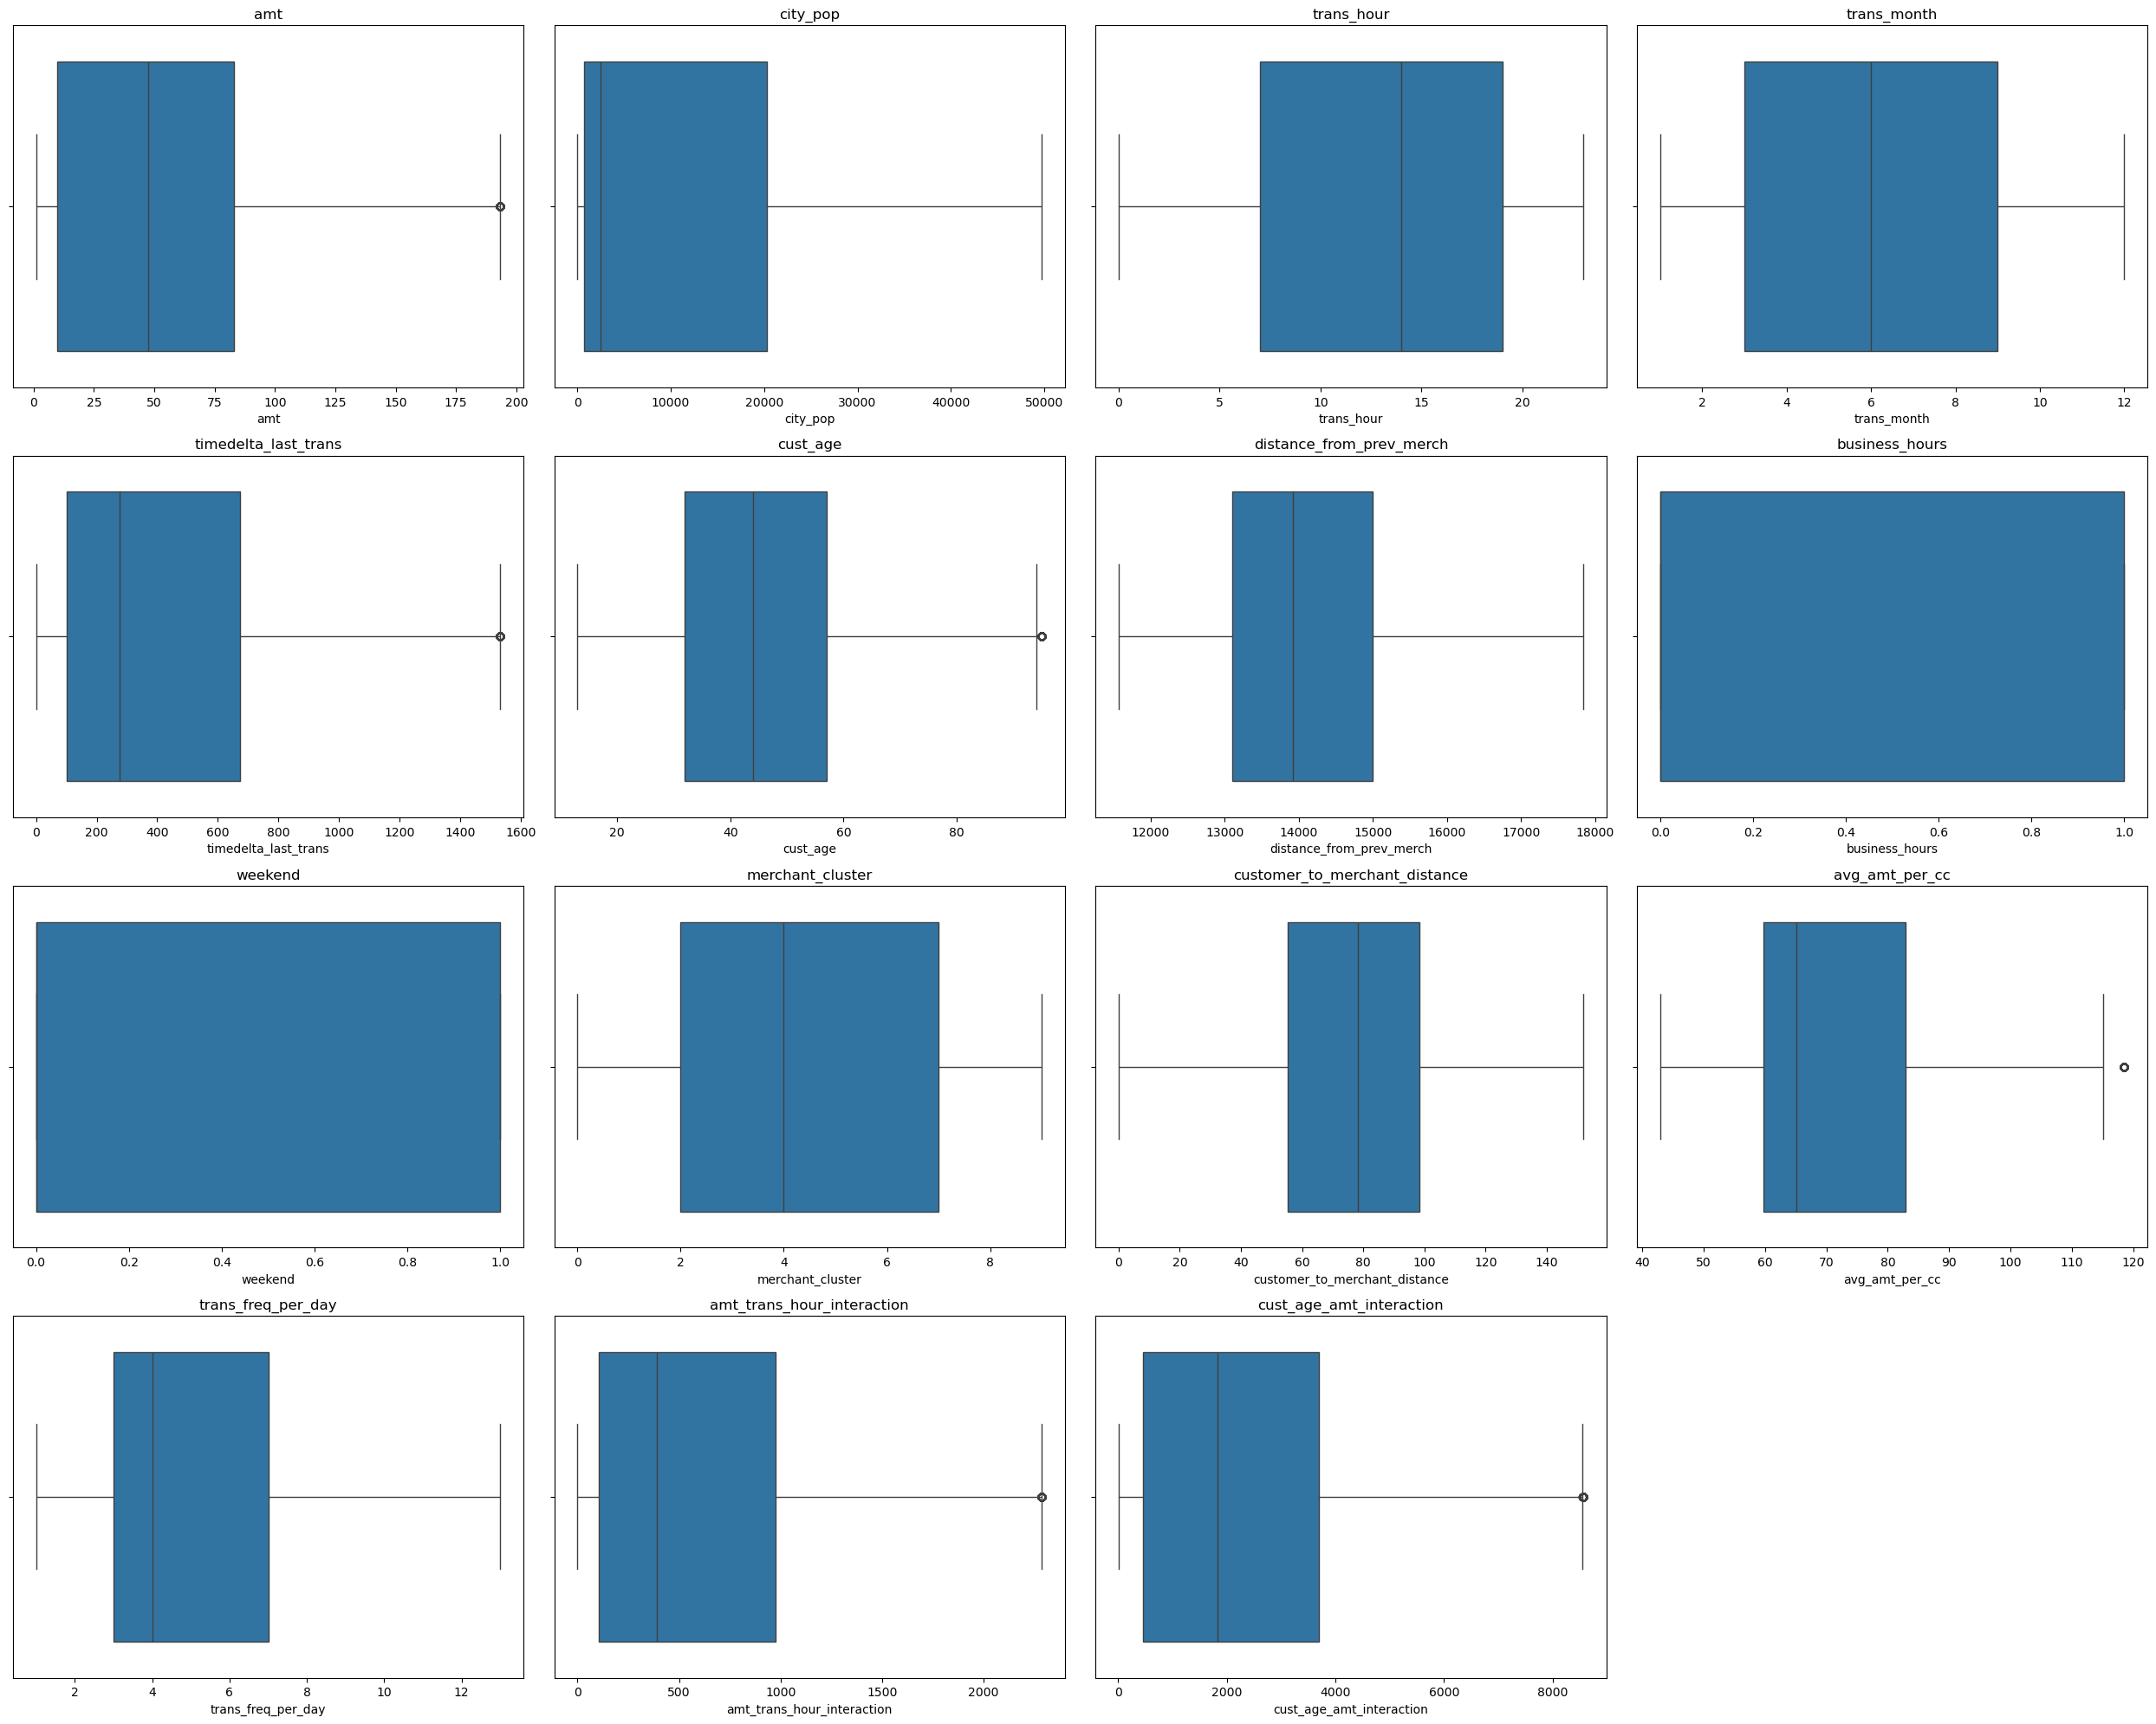

In [29]:
# checking for outliers after capping
num_cols = X_train.select_dtypes(include=[np.number]).columns

# Number of numerical columns
num_cols_count = len(num_cols)

# Determine the grid size
rows = (num_cols_count // 4) + 1 if num_cols_count % 4 != 0 else num_cols_count // 4
cols = 4

# Plotting
plt.figure(figsize=(25, 5 * rows))  # Adjust height to accommodate more rows

for ind, col_name in enumerate(num_cols):
    plot_var = X_train[col_name]
    plt.subplot(rows, cols, ind + 1)
    sns.boxplot(x=plot_var)
    plt.title(col_name)
    plt.axis('on')  # Show axis to make the plot clearer

plt.tight_layout()  # Adjust layout to prevent overlapping
plt.show()


- outliers have been capped

##### Categorical encoding

In [30]:
# importing categorical encoding
import category_encoders as ce
# importing job lib to save the encoder to be used to encode the unseen data later
import joblib

# Function to apply WOE encoding and save encoders
def apply_woe_and_save_encoders(X_train, X_val, y_train, columns, encoder_filename):
    woe_encoders = []
    for col in columns:
        woe = ce.WOEEncoder(cols=[col])
        
        # Fit the encoder on the training data
        X_train_transformed = woe.fit_transform(X_train[[col]], y_train)
        
        # Transform the validation data
        X_val_transformed = woe.transform(X_val[[col]])
        
        # Add the transformed columns to the original DataFrames
        new_col_name = f"{col}_WOE"
        X_train[new_col_name] = X_train_transformed[col]
        X_val[new_col_name] = X_val_transformed[col]
        
        # Store the encoder
        woe_encoders.append(woe)

    # Save the list of encoders
    joblib.dump(woe_encoders, encoder_filename)
    
    return X_train, X_val

# Categorical columns to encode
columns_to_encode = ['state', 'job', 'category', 'trans_dayofweek','merchant','city']

# Apply WOE encoding to training and validation data and save encoders
encoder_filename = 'woe_encoders_newFeatures.joblib'
X_train_encoded, X_val_encoded = apply_woe_and_save_encoders(X_train, X_val, y_train, columns_to_encode, encoder_filename)

In [31]:
#importing one hot encoding
from sklearn.preprocessing import OneHotEncoder
# creating one hot encoded function
def apply_one_hot_encoding(X_train, X_val, column):
    ohe = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' to avoid dummy variable trap
    
    # Fit the encoder on the training data
    ohe.fit(X_train[[column]])
    
    # Transform both training and validation data
    X_train_ohe = ohe.transform(X_train[[column]])
    X_val_ohe = ohe.transform(X_val[[column]])
    
    # Get new column names for the one-hot encoded columns
    ohe_columns = ohe.get_feature_names_out([column])
    
    # Create DataFrames from the one-hot encoded arrays
    X_train_ohe_df = pd.DataFrame(X_train_ohe, columns=ohe_columns, index=X_train.index)
    X_val_ohe_df = pd.DataFrame(X_val_ohe, columns=ohe_columns, index=X_val.index)
    
    # Concatenate the new one-hot encoded columns to the original DataFrames
    X_train = pd.concat([X_train, X_train_ohe_df], axis=1)
    X_val = pd.concat([X_val, X_val_ohe_df], axis=1)
    
    return X_train, X_val

# Gender column to be encoded
ohe_column = 'gender'

# Apply one-hot encoding to the gender column in the WOE-encoded DataFrames
X_train_encoded, X_val_encoded = apply_one_hot_encoding(X_train_encoded, X_val_encoded, ohe_column)

##### Normalizing the data using MinMaxscaler

In [32]:
# Columns to drop
columns_to_drop = ['category', 'gender', 'state', 'job', 'trans_dayofweek','city','merchant']

# Drop the specified columns from the training and validation sets
X_train_encoded = X_train_encoded.drop(columns=columns_to_drop)
X_val_encoded = X_val_encoded.drop(columns=columns_to_drop)

In [33]:
# Importing MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler on the training data
X_train_scaled = scaler.fit_transform(X_train_encoded)

# Transform the validation data
X_val_scaled = scaler.transform(X_val_encoded)

# Convert the transformed data back to DataFrames
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_encoded.columns, index=X_train_encoded.index)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=X_val_encoded.columns, index=X_val_encoded.index)


print(X_train_scaled_df.head())
print(X_val_scaled_df.head())

             amt  city_pop  trans_hour  trans_month  timedelta_last_trans  \
332099  0.345657  0.047743    0.391304     0.454545              0.335400   
13250   0.055513  1.000000    0.565217     0.000000              0.572920   
85129   0.026249  0.012681    0.608696     0.090909              0.255791   
325949  0.182132  0.003241    0.608696     0.454545              0.632953   
903602  0.023130  0.383052    0.913043     1.000000              0.095269   

        cust_age  distance_from_prev_merch  business_hours  weekend  \
332099  0.146341                  0.450749             1.0      0.0   
13250   0.414634                  0.268176             1.0      0.0   
85129   0.475610                  0.324890             1.0      0.0   
325949  0.731707                  0.274984             1.0      0.0   
903602  0.365854                  0.212649             0.0      0.0   

        merchant_cluster  ...  trans_freq_per_day  amt_trans_hour_interaction  \
332099          0.111111  ...

# Unseen test Data preprocessing

In [ ]:
import pandas as pd
import numpy as np
from geopy.distance import geodesic
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from feature_engine.outliers import Winsorizer
import category_encoders as ce
import joblib

# Load the unseen dataset
df_unseen = pd.read_csv('../../data/raw/Fraudtest.csv')

# Convert trans_date_trans_time to pandas datetime
df_unseen['trans_date_trans_time'] = pd.to_datetime(df_unseen['trans_date_trans_time'])

# Extract the transaction hour, month, and day of the week
df_unseen['trans_hour'] = df_unseen['trans_date_trans_time'].dt.hour
df_unseen['trans_month'] = df_unseen['trans_date_trans_time'].dt.month
df_unseen['trans_dayofweek'] = df_unseen['trans_date_trans_time'].dt.day_name()

# Convert unix_time to datetime
df_unseen['transaction_time'] = pd.to_datetime(df_unseen['unix_time'], unit='s')

# Sort by user (cc_num) and transaction time
df_unseen = df_unseen.sort_values(by=['cc_num', 'transaction_time'])

# Calculate the previous transaction time using shift and fill NaN values
df_unseen['unix_time_prev_trans'] = df_unseen.groupby(by=['cc_num'])['unix_time'].shift(1)
df_unseen = df_unseen.assign(unix_time_prev_trans=df_unseen['unix_time_prev_trans'].fillna(df_unseen['unix_time'] - 86400))

# Calculate the time delta in minutes between the previous and current transaction
df_unseen['timedelta_last_trans'] = (df_unseen['unix_time'] - df_unseen['unix_time_prev_trans']) // 60

# Convert columns to datetime and calculate age at the time of transaction
df_unseen['dob'] = pd.to_datetime(df_unseen['dob'])
df_unseen['cust_age'] = (df_unseen['trans_date_trans_time'] - df_unseen['dob']).dt.days // 365

# Define the Haversine function
def haversine(lat1, lon1, lat2, lon2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lon2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6371 * c
    return km

# Create a new DataFrame to perform calculations
df_calc_unseen = pd.DataFrame(df_unseen)

# Sort by user (cc_num) to ensure correct order of transactions
df_calc_unseen = df_calc_unseen.sort_values(by=['cc_num'])

# Shift latitude and longitude of the previous merchant to get the previous transaction's coordinates
df_calc_unseen['prev_merch_lat'] = df_calc_unseen.groupby('cc_num')['merch_lat'].shift(1)
df_calc_unseen['prev_merch_long'] = df_calc_unseen.groupby('cc_num')['merch_long'].shift(1)

# Fill null values with the current merchant's coordinates using assign method
df_calc_unseen = df_calc_unseen.assign(
    prev_merch_lat=df_calc_unseen['prev_merch_lat'].fillna(df_calc_unseen['merch_lat']),
    prev_merch_long=df_calc_unseen['prev_merch_long'].fillna(df_calc_unseen['merch_long'])
)

# Calculate the distance using the Haversine formula
df_calc_unseen['distance_from_prev_merch'] = df_calc_unseen.apply(
    lambda row: haversine(row['merch_lat'], row['merch_long'], row['prev_merch_lat'], row['prev_merch_long']), axis=1
)
# Add the calculated distances back to the original DataFrame
df_unseen['distance_from_prev_merch'] = df_calc_unseen['distance_from_prev_merch']

# Add business hours and weekend features
df_unseen['business_hours'] = df_unseen['trans_hour'].apply(lambda x: 1 if 9 <= x <= 18 else 0)
df_unseen['weekend'] = df_unseen['trans_dayofweek'].apply(lambda x: 1 if x in ['Saturday', 'Sunday'] else 0)

# Add merchant location clusters
coords_unseen = df_unseen[['merch_lat', 'merch_long']].dropna().values
kmeans = KMeans(n_clusters=10, random_state=42)
df_unseen['merchant_cluster'] = kmeans.fit_predict(coords_unseen)

# Calculate the distance between customer city and merchant city if applicable
def calculate_customer_to_merchant_distance(row):
    customer_coords = (row['lat'], row['long'])
    merchant_coords = (row['merch_lat'], row['merch_long'])
    return geodesic(customer_coords, merchant_coords).kilometers

df_unseen['customer_to_merchant_distance'] = df_unseen.apply(calculate_customer_to_merchant_distance, axis=1)

# Calculate average transaction amount per credit card
df_unseen['avg_amt_per_cc'] = df_unseen.groupby('cc_num')['amt'].transform('mean')

# Calculate transaction frequency per day for the same credit card
df_unseen['trans_freq_per_day'] = df_unseen.groupby(['cc_num', df_unseen['transaction_time'].dt.date])['trans_date_trans_time'].transform('count')

# Create interaction features
df_unseen['amt_trans_hour_interaction'] = df_unseen['amt'] * df_unseen['trans_hour']
df_unseen['cust_age_amt_interaction'] = df_unseen['cust_age'] * df_unseen['amt']

# List of columns to drop
drop_cols_unseen = [
    'Unnamed: 0', 'street', 'zip', 'first', 'last', 'trans_num', 'trans_date_trans_time',
    'transaction_time', 'cc_num', 'unix_time', 'unix_time_prev_trans', 'lat', 'long',
    'merch_lat', 'merch_long', 'dob'
]

# Dropping the columns from the DataFrame
df_unseen = df_unseen.drop(columns=drop_cols_unseen)

# Separate features and target variable
X_unseen = df_unseen.drop(columns=["is_fraud"])
y_unseen = df_unseen["is_fraud"]

# Apply outlier capping
outliers = ['amt', 'city_pop', 'timedelta_last_trans', 'distance_from_prev_merch', 'avg_amt_per_cc', 'trans_freq_per_day',
       'amt_trans_hour_interaction', 'cust_age_amt_interaction'] 
capper_iqr = Winsorizer(capping_method = 'iqr',tail = 'both', fold = 1.5, variables = outliers) 
capper_iqr.fit(X_unseen)
X_unseen = capper_iqr.transform(X_unseen)

# Load the saved WOE encoders
woe_encoders = joblib.load('woe_encoders_newFeatures.joblib')

# Apply WOE Encoding
def apply_woe(X, woe_columns, woe_encoders):
    for col, encoder in zip(woe_columns, woe_encoders):
        X_transformed = encoder.transform(X[[col]])
        new_col_name = f"{col}_WOE"
        X[new_col_name] = X_transformed[col]
    return X

woe_columns = ['state', 'job', 'category', 'trans_dayofweek','merchant','city']
X_unseen = apply_woe(X_unseen, woe_columns, woe_encoders)

# Apply One-Hot Encoding
ohe = OneHotEncoder(sparse_output=False, drop='first')
ohe.fit(X_unseen[['gender']])  # Fit on the unseen data

X_unseen_ohe = ohe.transform(X_unseen[['gender']])
ohe_columns = ohe.get_feature_names_out(['gender'])
X_unseen_ohe_df = pd.DataFrame(X_unseen_ohe, columns=ohe_columns, index=X_unseen.index)
X_unseen = pd.concat([X_unseen, X_unseen_ohe_df], axis=1)
X_unseen.drop(columns=['gender'], inplace=True)

# Drop redundant columns
columns_to_drop = ['category', 'state', 'job', 'trans_dayofweek','city','merchant']
X_unseen.drop(columns=columns_to_drop, inplace=True)

# Apply MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X_train_encoded)  # Fit on the training data

X_unseen_scaled = scaler.transform(X_unseen)
X_unseen_scaled_df = pd.DataFrame(X_unseen_scaled, columns=X_unseen.columns, index=X_unseen.index)

# Display a sample of the final DataFrame for unseen data
print("\nFinal Unseen DataFrame Sample:")
print(X_unseen_scaled_df.head())

# Model building and evaluation
#### 1. XGBoost using cost-sensitive learning

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from collections import Counter
import numpy as np

# Calculate scale_pos_weight using the square root of the ratio
counter = Counter(y_train)
scale_pos_weight = np.sqrt(counter[0] / counter[1])

print("Scale Pos Weight:", scale_pos_weight)
print('Estimate for scale_pos_weight: %.3f' % scale_pos_weight)

# Define the initial XGBoost model
xgb_model = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42)

# Train the model on the training data
xgb_model.fit(X_train_scaled_df, y_train)

# Make predictions on the validation data
y_val_pred = xgb_model.predict(X_val_scaled_df)
y_val_pred_proba = xgb_model.predict_proba(X_val_scaled_df)[:, 1]

# Evaluate the model on the validation data
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Classification Report:\n", classification_report(y_val, y_val_pred))
print("Validation Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))
print("Validation ROC AUC Score:", roc_auc_score(y_val, y_val_pred_proba))
print("Validation PR AUC Score:", average_precision_score(y_val, y_val_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

In [ ]:
# Make predictions on the unseen data with the base model
y_unseen_pred = xgb_model.predict(X_unseen_scaled_df)
y_unseen_pred_proba = xgb_model.predict_proba(X_unseen_scaled_df)[:, 1]

# Evaluate the model on the unseen data
print("Unseen Data Accuracy:", accuracy_score(y_unseen, y_unseen_pred))
print("Unseen Data Classification Report:\n", classification_report(y_unseen, y_unseen_pred))
print("Unseen Data Confusion Matrix:\n", confusion_matrix(y_unseen, y_unseen_pred))
print("Unseen Data ROC AUC Score:", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score:", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

In [38]:
%%time
from sklearn.model_selection import cross_validate, StratifiedKFold

# Initialize StratifiedKFold
strat_k_fold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Define the scoring metrics
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Perform cross-validation
cv_results = cross_validate(xgb_model, X_train_scaled_df, y_train, cv=strat_k_fold, scoring=scoring, return_train_score=True)

# Print cross-validation results
print("Cross-Validation Results:")
for score in scoring:
    print(f"{score.capitalize()} - Train: {np.mean(cv_results['train_' + score]):.4f} ± {np.std(cv_results['train_' + score]):.4f}, Test: {np.mean(cv_results['test_' + score]):.4f} ± {np.std(cv_results['test_' + score]):.4f}")


Cross-Validation Results:
Accuracy - Train: 0.9997 ± 0.0000, Test: 0.9991 ± 0.0001
Precision - Train: 0.9569 ± 0.0034, Test: 0.9096 ± 0.0065
Recall - Train: 1.0000 ± 0.0001, Test: 0.9309 ± 0.0104
F1 - Train: 0.9780 ± 0.0018, Test: 0.9201 ± 0.0070
Roc_auc - Train: 1.0000 ± 0.0000, Test: 0.9994 ± 0.0003
CPU times: total: 5min 38s
Wall time: 24.6 s


In [39]:
%%time
from skopt import BayesSearchCV
from skopt.space import Integer, Real
import joblib
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold

# Define the XGBoost model
xgb_model_tuned = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Define the parameter grid
param_grid = {
    'scale_pos_weight': Integer(1, 1000),
    'n_estimators': Integer(50, 200),
    'max_depth': Integer(1, 30),
    'learning_rate': Real(0.01, 0.2, prior='log-uniform')
}

# Initialize StratifiedKFold
strat_k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize the Bayesian Search CV
bayes_search = BayesSearchCV(
    estimator=xgb_model_tuned,
    search_spaces=param_grid,
    cv=strat_k_fold,
    scoring='roc_auc',  # Optimize for roc_auc
    n_jobs=-1,  # Use all available processors
    n_iter=32,  # Number of parameter settings that are sampled
    random_state=42,
    refit=True
)

# Perform the search
bayes_search.fit(X_train_scaled_df, y_train)

# Best parameters and score
print("Best Parameters:", bayes_search.best_params_)
print("Best Cross-Validation ROC AUC Score:", bayes_search.best_score_)


C:\Users\Black\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [03:50:08] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-06abd128ca6c1688d-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best Parameters: OrderedDict([('learning_rate', 0.2), ('max_depth', 30), ('n_estimators', 200), ('scale_pos_weight', 85)])
Best Cross-Validation ROC AUC Score: 0.9992798066540137
CPU times: total: 1min 28s
Wall time: 9min 9s


Unseen Data Accuracy (Fixed Threshold): 0.9973205882829271
Unseen Data Classification Report (Fixed Threshold):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.83      0.38      0.52      2145

    accuracy                           1.00    555719
   macro avg       0.92      0.69      0.76    555719
weighted avg       1.00      1.00      1.00    555719

Unseen Data Confusion Matrix (Fixed Threshold):
TN: 553410, FP: 164, FN: 1325, TP: 820
[[553410    164]
 [  1325    820]]
Unseen Data ROC AUC Score (Fixed Threshold): 0.9836696336886013
Unseen Data PR AUC Score (Fixed Threshold): 0.6707332357334836


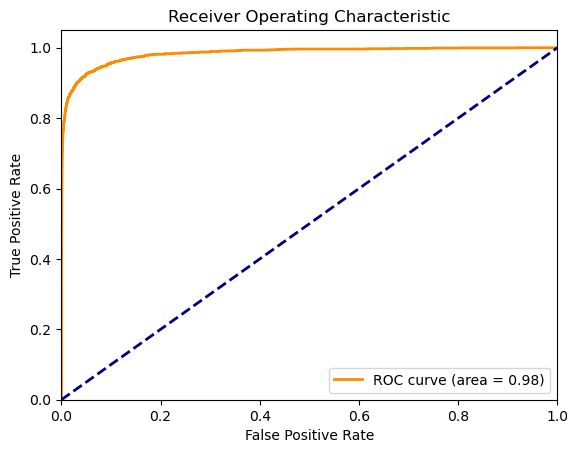

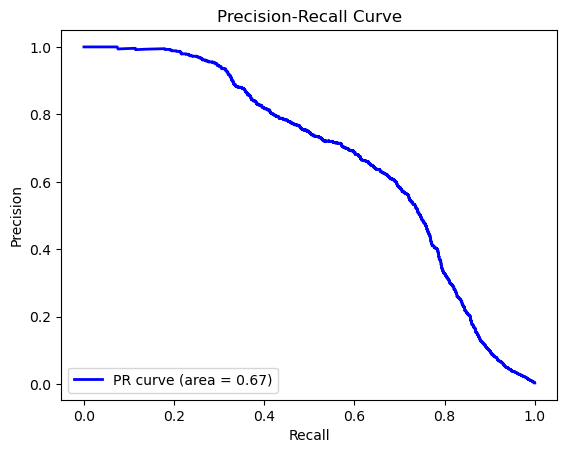

In [40]:
# Use the best model for predictions
best_xgb_model = bayes_search.best_estimator_

# Make predictions on the unseen data
y_unseen_pred_proba = best_xgb_model.predict_proba(X_unseen_scaled_df)[:, 1]

# Apply the fixed threshold of 0.5 to the predictions
fixed_threshold = 0.5
y_unseen_pred_fixed = (y_unseen_pred_proba >= fixed_threshold).astype(int)

# Evaluate the fixed threshold predictions
print("Unseen Data Accuracy (Fixed Threshold):", accuracy_score(y_unseen, y_unseen_pred_fixed))
print("Unseen Data Classification Report (Fixed Threshold):\n", classification_report(y_unseen, y_unseen_pred_fixed))

# Get the confusion matrix
cm = confusion_matrix(y_unseen, y_unseen_pred_fixed)
tn, fp, fn, tp = cm.ravel()

print("Unseen Data Confusion Matrix (Fixed Threshold):")
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
print(cm)

print("Unseen Data ROC AUC Score (Fixed Threshold):", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score (Fixed Threshold):", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

C:\Users\Black\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [04:00:24] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-06abd128ca6c1688d-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Validation Accuracy: 0.9985
Validation Precision: 0.8663
Validation Recall: 0.8859
Validation F1 Score: 0.8760
Validation ROC-AUC: 0.9978
Validation PR AUC: 0.9387
Validation Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    386751
           1       0.87      0.89      0.88      2252

    accuracy                           1.00    389003
   macro avg       0.93      0.94      0.94    389003
weighted avg       1.00      1.00      1.00    389003

Validation Confusion Matrix:
[[386443    308]
 [   257   1995]]
True Positives (TP): 1995
False Positives (FP): 308
True Negatives (TN): 386443
False Negatives (FN): 257


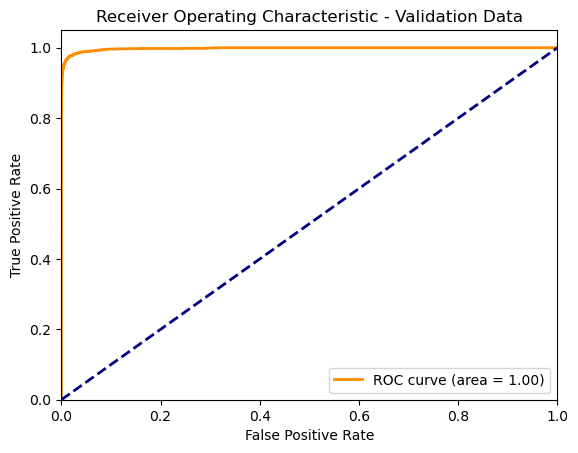

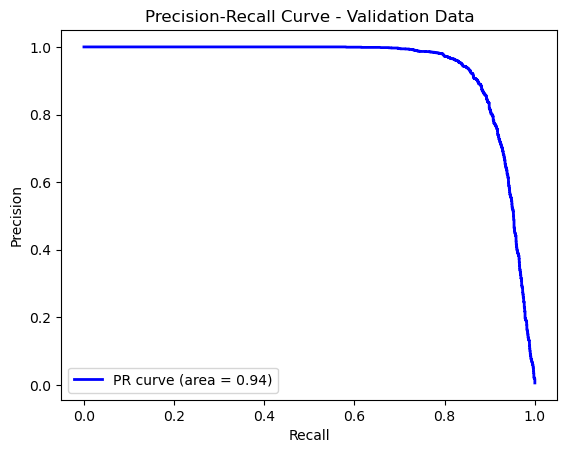

In [41]:
from imblearn.over_sampling import ADASYN
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, classification_report, confusion_matrix, precision_recall_curve, roc_curve, auc
import matplotlib.pyplot as plt

best_xgb_model_ADASYN = bayes_search.best_estimator_
# Initialize ADASYN
adasyn = ADASYN(random_state=42)

# Resample the training data using ADASYN
X_resampled, y_resampled = adasyn.fit_resample(X_train_scaled_df, y_train)

# Fit the best XGBoost model on the resampled data
best_xgb_model_ADASYN.fit(X_resampled, y_resampled)

# Model evaluation on validation data
y_val_pred = best_xgb_model_ADASYN.predict(X_val_scaled_df)
y_val_pred_proba = best_xgb_model_ADASYN.predict_proba(X_val_scaled_df)[:, 1]

accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_pred_proba)
precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_val_pred_proba)
pr_auc = auc(recall_vals, precision_vals)

conf_matrix = confusion_matrix(y_val, y_val_pred)
tn, fp, fn, tp = conf_matrix.ravel()

print(f'Validation Accuracy: {accuracy:.4f}')
print(f'Validation Precision: {precision:.4f}')
print(f'Validation Recall: {recall:.4f}')
print(f'Validation F1 Score: {f1:.4f}')
print(f'Validation ROC-AUC: {roc_auc:.4f}')
print(f'Validation PR AUC: {pr_auc:.4f}')
print("Validation Classification Report:")
print(classification_report(y_val, y_val_pred))
print("Validation Confusion Matrix:")
print(conf_matrix)
print(f'True Positives (TP): {tp}')
print(f'False Positives (FP): {fp}')
print(f'True Negatives (TN): {tn}')
print(f'False Negatives (FN): {fn}')

# Plot ROC Curve for validation data
fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Validation Data')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve for validation data
precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Validation Data')
plt.legend(loc="lower left")
plt.show()



Unseen Data Accuracy: 0.9964
Unseen Data Precision: 0.5572
Unseen Data Recall: 0.3315
Unseen Data F1 Score: 0.4157
Unseen Data ROC-AUC: 0.9670
Unseen Data PR AUC: 0.4492
Unseen Data Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.56      0.33      0.42      2145

    accuracy                           1.00    555719
   macro avg       0.78      0.67      0.71    555719
weighted avg       1.00      1.00      1.00    555719

Unseen Data Confusion Matrix:
[[553009    565]
 [  1434    711]]
True Positives (TP): 711
False Positives (FP): 565
True Negatives (TN): 553009
False Negatives (FN): 1434


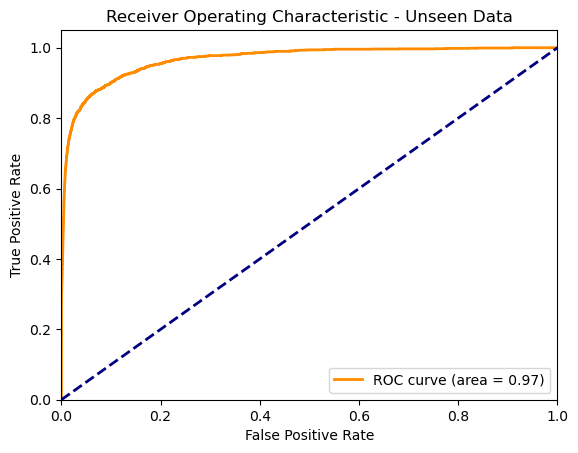

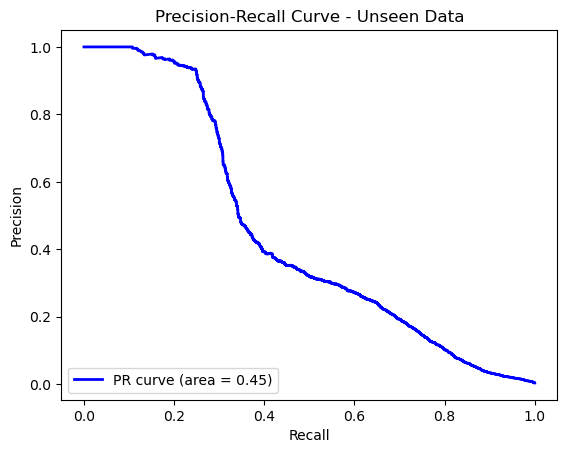

In [42]:
# Model evaluation on unseen data
y_unseen_pred = best_xgb_model_ADASYN.predict(X_unseen_scaled_df)
y_unseen_pred_proba = best_xgb_model_ADASYN.predict_proba(X_unseen_scaled_df)[:, 1]

accuracy_unseen = accuracy_score(y_unseen, y_unseen_pred)
precision_unseen = precision_score(y_unseen, y_unseen_pred)
recall_unseen = recall_score(y_unseen, y_unseen_pred)
f1_unseen = f1_score(y_unseen, y_unseen_pred)
roc_auc_unseen = roc_auc_score(y_unseen, y_unseen_pred_proba)
precision_vals_unseen, recall_vals_unseen, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc_unseen = auc(recall_vals_unseen, precision_vals_unseen)

conf_matrix_unseen = confusion_matrix(y_unseen, y_unseen_pred)
tn_unseen, fp_unseen, fn_unseen, tp_unseen = conf_matrix_unseen.ravel()

print(f'Unseen Data Accuracy: {accuracy_unseen:.4f}')
print(f'Unseen Data Precision: {precision_unseen:.4f}')
print(f'Unseen Data Recall: {recall_unseen:.4f}')
print(f'Unseen Data F1 Score: {f1_unseen:.4f}')
print(f'Unseen Data ROC-AUC: {roc_auc_unseen:.4f}')
print(f'Unseen Data PR AUC: {pr_auc_unseen:.4f}')
print("Unseen Data Classification Report:")
print(classification_report(y_unseen, y_unseen_pred))
print("Unseen Data Confusion Matrix:")
print(conf_matrix_unseen)
print(f'True Positives (TP): {tp_unseen}')
print(f'False Positives (FP): {fp_unseen}')
print(f'True Negatives (TN): {tn_unseen}')
print(f'False Negatives (FN): {fn_unseen}')

# Plot ROC Curve for unseen data
fpr_unseen, tpr_unseen, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc_unseen = auc(fpr_unseen, tpr_unseen)
plt.figure()
plt.plot(fpr_unseen, tpr_unseen, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_unseen)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Unseen Data')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve for unseen data
precision_unseen, recall_unseen, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc_unseen = auc(recall_unseen, precision_unseen)
plt.figure()
plt.plot(recall_unseen, precision_unseen, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc_unseen)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Unseen Data')
plt.legend(loc="lower left")
plt.show()
